# Lecture 5: Exercise 1 - Solution

## Objective

The goal of this assignment is to build several transformer-based models for sentiment analysis prediction. You should therefore compare different BERT-based approaches (pre-trained models, frozen BERT embeddings with classifiers, and fine-tuning) and optionally explore prompt-based sentiment analysis using LLMs.

## Data

You will use Kaggle data ([LINK](https://www.kaggle.com/datasets/d4rklucif3r/restaurant-reviews)) about restaurant reviews and whether or not customers liked it. 

## Tasks 

- **Approach 1: Pre-trained transformer model**
  - Use a **pre-trained sentiment analysis model** from Hugging Face (e.g., `cardiffnlp/twitter-roberta-base-sentiment`, `distilbert-base-uncased-finetuned-sst-2-english`, or similar).
  - Apply the model directly to your test data **without any additional training**.
  - Evaluate its zero-shot performance on your dataset.

- **Approach 2: Frozen BERT embeddings + classifier**
  - Extract **contextualized embeddings** from a pre-trained BERT model (e.g., `bert-base-uncased`).
  - **Freeze the BERT weights** (no fine-tuning of the transformer).
  - Experiment with different **pooling strategies** (CLS token, mean pooling, max pooling).
  - Train **at least two traditional classifiers** on top of these embeddings (e.g., Logistic Regression, Random Forest, SVM).

- **Approach 3: Fine-tuning BERT**
  - Fine-tune a **pre-trained BERT model** (e.g., `bert-base-uncased`) on your labeled training data.
  - Optionally: Compare **full fine-tuning** (all layers) vs. **partial fine-tuning** (last few layers only).
  - Use appropriate training arguments (learning rate, batch size, epochs, etc.).

- **Approach 4 (Optional/Bonus): Prompt-based sentiment analysis with LLMs**
  - Use a **local LLM** via Ollama (e.g., `phi3:mini`, `llama3.2:1b`) or an API-based LLM.
  - Design **at least two different prompting strategies** (e.g., simple instruction, few-shot learning).
  - Evaluate the LLM's sentiment predictions on your test set.
  - **Note**: Consider computational costs and dataset size for this approach.

- **Evaluate model performance**
  - Assess each model using the following metrics: **AUC, Accuracy, Precision, Recall, F1-Score**.
  - Create **ROC curves** comparing all approaches.
  - Analyze the **confusion matrix** for each model.

- **Compare and analyze results**
  - Create a **summary table** comparing all approaches across all metrics.
  - Discuss the **trade-offs** between approaches:
    - Performance (which approach works best?)
    - Interpretability and practical considerations
  - Identify which approach works best for your dataset and **explain why**.


## Solution

This solution implements a comprehensive transformer-based sentiment analysis pipeline comparing:
- **Pre-trained approach**: RoBERTa model fine-tuned on Twitter sentiment (zero-shot transfer)
- **Feature extraction approach**: Frozen BERT embeddings with traditional classifiers (analogous to LSA baseline from Lecture 4)
- **Fine-tuning approach**: Full BERT fine-tuning on restaurant reviews (maximum performance)
- **Prompt-based approach (bonus)**: Few-shot learning with local LLM via Ollama + Phi-3

**Key implementation details:**
- **No preprocessing required**: Transformers handle text internally via subword tokenization (unlike TF-IDF/LSA)
- **Pooling strategies**: CLS token vs mean pooling for frozen BERT embeddings
- **Multiple classifiers**: Logistic Regression (L1 regularized), Random Forest, SVM with hyperparameter tuning
- **Proper evaluation**: Consistent train/test split (80/20) with stratification  
- **GPU acceleration**: Automatic device selection (CUDA/MPS/CPU)
- **Reproducibility**: Fixed random seeds and stratified cross-validation


### Step 1: Import Libraries and Configure Environment

Import all required packages and configure the environment to suppress warnings and ensure reproducibility.

In [3]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, 
    roc_curve, classification_report,
    precision_recall_fscore_support
)

import torch
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset

import time
import warnings

# Try importing ollama (optional for bonus section)
try:
    import ollama
    OLLAMA_AVAILABLE = True
except ImportError:
    OLLAMA_AVAILABLE = False
    print("⚠ Ollama not installed. Bonus section (Approach 4) will be skipped.")

# Settings
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # Suppress tokenizer warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print("✓ All packages loaded successfully!")

/Users/matthiasbogaert/anaconda3/envs/SMWA2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All packages loaded successfully!


### Step 2: Check Device Configuration

Transformers benefit significantly from GPU acceleration.

In [4]:
# Check PyTorch device availability
print("="*70)
print("PYTORCH DEVICE CONFIGURATION")
print("="*70)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✓ CUDA GPU available: {torch.cuda.get_device_name(0)}")
    print(f"  Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Apple Silicon GPU (MPS) available")
else:
    device = torch.device("cpu")
    print("⚠ No GPU available, using CPU")
    print("  Note: Training will be significantly slower on CPU")

print(f"\nUsing device: {device}")
print("="*70)

PYTORCH DEVICE CONFIGURATION
✓ Apple Silicon GPU (MPS) available

Using device: mps


### Step 3: Load and Explore Data

Load the restaurant reviews dataset from Kaggle.

**Important difference from Lecture 4**: Unlike traditional ML approaches that require extensive text preprocessing (TF-IDF, LSA requires lowercase, punctuation removal, stopword filtering), **transformers do NOT require manual preprocessing**. 

Modern transformer tokenizers (WordPiece, BPE) handle:
  - **Capitalization**: Preserved as useful signal ("AMAZING!" vs "amazing")
  - **Punctuation**: Critical for sentiment ("not good!" vs "not good")
  - **Subword tokenization**: Handles misspellings and rare words automatically
  - **Special tokens**: Adds [CLS], [SEP] automatically

We load the **raw text** directly and let the transformer tokenizer handle all preprocessing.

In [6]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/d4rklucif3r/restaurant-reviews

df = pd.read_csv('./Data/Restaurant_Reviews.tsv', delimiter='\t', quoting=3)

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nColumn names:", df.columns.tolist())
print("\nClass distribution:")
print(df['Liked'].value_counts())
print(f"\nClass balance: {df['Liked'].value_counts(normalize=True)}")

Dataset shape: (1000, 2)

First few rows:
                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1

Column names: ['Review', 'Liked']

Class distribution:
Liked
1    500
0    500
Name: count, dtype: int64

Class balance: Liked
1    0.5
0    0.5
Name: proportion, dtype: float64


In [7]:
# Prepare the data (use raw text, no preprocessing)
X = df['Review'].values  # Raw text
y = df['Liked'].values

print(f"Total samples: {len(X)}")
print(f"Positive samples: {sum(y)} ({sum(y)/len(y)*100:.1f}%)")
print(f"Negative samples: {len(y) - sum(y)} ({(len(y)-sum(y))/len(y)*100:.1f}%)")

# Example reviews
print("\n" + "="*70)
print("Example positive review:")
print(f"  \"{X[y==1][0]}\"")
print("\nExample negative review:")
print(f"  \"{X[y==0][0]}\"")
print("="*70)

Total samples: 1000
Positive samples: 500 (50.0%)
Negative samples: 500 (50.0%)

Example positive review:
  "Wow... Loved this place."

Example negative review:
  "Crust is not good."


### Step 4: Train/Test Split

Create a **consistent train/test split (80/20)** used across all models to ensure fair comparison.

**Rationale for 80/20 split**:
- **800 training samples**: Sufficient for fine-tuning BERT (minimum ~500 recommended)
- **200 test samples**: Adequate for reliable evaluation (statistically sufficient)
- **Stratification**: Maintains class balance in both train and test sets

**Note**: This is more generous than Lecture 4's 60/40 split because:
1. Transformers (especially fine-tuning) benefit from more training data
2. Pre-trained models are more robust, so fewer test samples are acceptable
3. 200 test samples still provide reliable performance estimates (95% CI: ±7%)

In [8]:
# Create train/test split (same split for all models)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTrain class distribution: {np.bincount(y_train)}")
print(f"  Positive: {np.bincount(y_train)[1]} ({np.bincount(y_train)[1]/len(y_train)*100:.1f}%)")
print(f"  Negative: {np.bincount(y_train)[0]} ({np.bincount(y_train)[0]/len(y_train)*100:.1f}%)")
print(f"\nTest class distribution: {np.bincount(y_test)}")
print(f"  Positive: {np.bincount(y_test)[1]} ({np.bincount(y_test)[1]/len(y_test)*100:.1f}%)")
print(f"  Negative: {np.bincount(y_test)[0]} ({np.bincount(y_test)[0]/len(y_test)*100:.1f}%)")

Training set size: 800
Test set size: 200

Train class distribution: [400 400]
  Positive: 400 (50.0%)
  Negative: 400 (50.0%)

Test class distribution: [100 100]
  Positive: 100 (50.0%)
  Negative: 100 (50.0%)


### Approach 1: Pre-trained Transformer (Zero-Shot Transfer Learning)

Use a **fully pre-trained sentiment model** directly without any additional training. This demonstrates **transfer learning** at its simplest: apply knowledge learned on one domain (Twitter) to another (restaurant reviews).

**Model**: `cardiffnlp/twitter-roberta-base-sentiment-latest`

**Implementation note**: We map the 3-class output to binary by treating `neutral` and `positive` as positive (1), which is reasonable for restaurant reviews where "OK" typically means "liked".

In [9]:
# Load pre-trained sentiment analysis pipeline
print("Loading pre-trained RoBERTa sentiment model...")
print("This may take a minute on first run (downloading model)...\n")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=0 if torch.cuda.is_available() else -1  # Use GPU if available
)

print("✓ Model loaded successfully!")
print(f"Model: {sentiment_pipeline.model.config._name_or_path}")
print(f"Model size: {sentiment_pipeline.model.num_parameters() / 1e6:.1f}M parameters")

Loading pre-trained RoBERTa sentiment model...
This may take a minute on first run (downloading model)...



Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


✓ Model loaded successfully!
Model: cardiffnlp/twitter-roberta-base-sentiment-latest
Model size: 124.6M parameters


In [11]:
# Evaluate on test set
print("\nEvaluating pre-trained model on test set...")
print("This may take a few minutes...\n")

predictions = []
confidences = []

for i, text in enumerate(X_test):
    if (i + 1) % 20 == 0:
        print(f"Progress: {i+1}/{len(X_test)}", end='\r')
    
    # Truncate to max length (512 tokens) to avoid warnings
    result = sentiment_pipeline(text[:512])[0]
    
    # Map 3-class labels to binary
    # neutral and positive → liked (1), negative → disliked (0)
    if result['label'] in ['positive', 'neutral', 'LABEL_2', 'LABEL_1']:
        pred = 1
    else:
        pred = 0
    
    predictions.append(pred)
    confidences.append(result['score'])


# Convert to numpy array
y_pred_pretrained = np.array(predictions)
y_pred_prob_pretrained = y_pred_pretrained.astype(float)  # Binary predictions as probabilities

# Calculate metrics
auc_pretrained = roc_auc_score(y_test, y_pred_pretrained)
accuracy_pretrained = accuracy_score(y_test, y_pred_pretrained)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_pretrained, average='binary'
)
cm_pretrained = confusion_matrix(y_test, y_pred_pretrained)

print("\n" + "="*70)
print("APPROACH 1: PRE-TRAINED ROBERTA RESULTS")
print("="*70)
print(f"AUC:       {auc_pretrained:.4f}")
print(f"Accuracy:  {accuracy_pretrained:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(f"  TN: {cm_pretrained[0,0]:3d}  FP: {cm_pretrained[0,1]:3d}")
print(f"  FN: {cm_pretrained[1,0]:3d}  TP: {cm_pretrained[1,1]:3d}")
print("="*70)

# Calculate sensitivity and specificity
tn, fp, fn, tp = cm_pretrained.ravel()
sensitivity_pretrained = tp / (tp + fn)
specificity_pretrained = tn / (tn + fp)
print(f"Sensitivity (Recall): {sensitivity_pretrained:.4f}")
print(f"Specificity:          {specificity_pretrained:.4f}")
print("="*70)


Evaluating pre-trained model on test set...
This may take a few minutes...

Progress: 200/200
APPROACH 1: PRE-TRAINED ROBERTA RESULTS
AUC:       0.9050
Accuracy:  0.9050
Precision: 0.8584
Recall:    0.9700
F1-Score:  0.9108

Confusion Matrix:
  TN:  84  FP:  16
  FN:   3  TP:  97
Sensitivity (Recall): 0.9700
Specificity:          0.8400


### Approach 2: Frozen RoBERTa Embeddings + Classifiers (Feature Extraction Baseline)

Extract **frozen contextualized embeddings** from pre-trained RoBERTa and train traditional classifiers on top. This approach is **analogous to Lecture 4's LSA baseline**, but with much richer semantic representations from transformers.

We will use **RoBERTa** (Robustly Optimized BERT) instead of BERT since it typically achieves **better performance**. 

**Key differences from Approach 1**:
- We train a **separate classifier** on top of embeddings, so not only inference
- Allows comparison of different **pooling strategies** and **classifiers**

**Pooling strategies** to compare:
1. **CLS token pooling**: Use the [CLS] token embedding (position 0). RoBERTa is specifically pre-trained to aggregate sequence information into this token for classification tasks.
2. **Mean pooling**: Average embeddings across all valid tokens (excluding padding). Explicitly captures information from the entire sequence.

**Classifiers** to compare:
1. **Logistic Regression** with L1 regularization (tuned via GridSearchCV)
2. **Random Forest** with default parameters
3. **Support Vector Machine** with RBF kernel

**Technical note**: Unlike LSA (Lecture 4) where we used pipelines with GridSearchCV, here we **extract embeddings once** and then train multiple classifiers. This is more efficient because embedding extraction is expensive (~30 seconds).

#### Load RoBERTa Model for Feature Extraction

In [13]:
# Load RoBERTa model and tokenizer
print("Loading RoBERTa model for feature extraction...")
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)
bert_model.eval()  # Set to evaluation mode (disables dropout)

print("✓ RoBERTa model loaded successfully!")
print(f"Model: {model_name}")
print(f"Model size: {bert_model.num_parameters() / 1e6:.1f}M parameters")
print(f"Embedding dimension: {bert_model.config.hidden_size}")
print(f"Max sequence length: {bert_model.config.max_position_embeddings}")

Loading RoBERTa model for feature extraction...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ RoBERTa model loaded successfully!
Model: roberta-base
Model size: 124.6M parameters
Embedding dimension: 768
Max sequence length: 514


#### Extract RoBERTa Embeddings with Different Pooling Strategies

Define a function to extract RoBERTa embeddings using different pooling methods.

**Why pooling is necessary**:
RoBERTa outputs a **768-dimensional vector for each token** in the input. For a review with 50 tokens, this gives us a 50×768 matrix. We need a **single fixed-size vector per document** to feed into traditional classifiers.

**Pooling methods**:
- **CLS pooling**: Use only the [CLS] token embedding (position 0). Transformer models are pre-trained to aggregate sequence-level information into this token for classification tasks.
- **Mean pooling**: Average embeddings across all **valid tokens** (excluding padding). This explicitly captures information from the entire sequence rather than relying on aggregation in [CLS].

**Implementation details**:
- Use `torch.no_grad()` to prevent gradient computation (saves memory, faster)
- Apply **attention mask** for mean pooling to exclude padding tokens from average
- Process texts one-by-one (batch processing would be faster but adds complexity)

In [14]:
def get_bert_embeddings(texts, pooling='cls'):
    """
    Extract RoBERTa embeddings for a list of texts.
    
    Args:
        texts: List or array of text strings
        pooling: 'cls' or 'mean'
    
    Returns:
        numpy array of embeddings (n_samples, 768)
    """
    embeddings = []
    
    with torch.no_grad():  # Disable gradient computation
        for i, text in enumerate(texts):
            if (i + 1) % 50 == 0:
                print(f"Processing: {i+1}/{len(texts)}", end='\r')
            
            # Tokenize (truncate to 512 tokens max)
            encoded = tokenizer(
                text,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors='pt'
            )
            
            # Move to device (GPU or CPU)
            encoded = {key: val.to(device) for key, val in encoded.items()}
            
            # Get RoBERTa outputs
            outputs = bert_model(**encoded)
            hidden_states = outputs.last_hidden_state  # Shape: (1, seq_len, 768)
            
            # Apply pooling
            if pooling == 'cls':
                # Use CLS token (first token, position 0)
                embedding = hidden_states[:, 0, :].cpu().numpy()
            elif pooling == 'mean':
                # Mean pooling over all valid tokens (exclude padding)
                attention_mask = encoded['attention_mask'].unsqueeze(-1)  # (1, seq_len, 1)
                masked_hidden = hidden_states * attention_mask  # Zero out padding
                sum_hidden = masked_hidden.sum(1)  # Sum over sequence
                sum_mask = attention_mask.sum(1)  # Count valid tokens
                embedding = (sum_hidden / sum_mask).cpu().numpy()  # Average
            else:
                raise ValueError(f"Unknown pooling: {pooling}")
            
            embeddings.append(embedding[0])
    
    print()  # Newline after progress
    return np.array(embeddings)

print("✓ Embedding extraction function defined!")

✓ Embedding extraction function defined!


#### Extract Embeddings for Train and Test Sets

Extract embeddings using both CLS and mean pooling.

**Memory efficient**: We extract embeddings once and reuse them for all classifiers.

In [ ]:
# Extract embeddings with CLS pooling
print("Extracting RoBERTa embeddings (CLS pooling)...")
print("This may take 1-2 minutes...\n")

X_train_bert_cls = get_bert_embeddings(X_train, pooling='cls')
X_test_bert_cls = get_bert_embeddings(X_test, pooling='cls')

print(f"Training embeddings shape: {X_train_bert_cls.shape}")
print(f"Test embeddings shape: {X_test_bert_cls.shape}")

Extracting RoBERTa embeddings (CLS pooling)...
This may take 1-2 minutes...

Processing: 800/800
Processing: 200/200
✓ CLS embeddings extracted in 20.51 seconds
Training embeddings shape: (800, 768)
Test embeddings shape: (200, 768)


In [17]:
# Extract embeddings with mean pooling
print("\nExtracting RoBERTa embeddings (Mean pooling)...")
X_train_bert_mean = get_bert_embeddings(X_train, pooling='mean')
X_test_bert_mean = get_bert_embeddings(X_test, pooling='mean')

print(f"Training embeddings shape: {X_train_bert_mean.shape}")
print(f"Test embeddings shape: {X_test_bert_mean.shape}")


Extracting RoBERTa embeddings (Mean pooling)...
Processing: 800/800
Processing: 200/200
Training embeddings shape: (800, 768)
Test embeddings shape: (200, 768)


#### Train Classifiers on BERT Embeddings

Now we train traditional classifiers on the extracted embeddings. We compare:
1. **Logistic Regression** with L1 regularization (Lasso) - tuned via GridSearchCV
2. **Random Forest** with default parameters
3. **Support Vector Machine** with RBF kernel

**Why L1 regularization for Logistic Regression**:
- Prevents overfitting on high-dimensional (768-D) embedding space
- Regularization strength `C` is tuned via 5-fold stratified cross-validation

**Why StandardScaler**:
- Logistic Regression and SVM are **sensitive to feature scales**
- Random Forest is **scale-invariant** (tree-based), so no scaling needed

##### Classifier 1: Logistic Regression (CLS Pooling) with Hyperparameter Tuning

Use GridSearchCV to find the best regularization strength `C` for L1-penalized Logistic Regression.

In [18]:
# Train Logistic Regression on CLS embeddings with Grid Search
print("Training Logistic Regression (CLS pooling) with GridSearchCV...")
print("This may take 10-20 seconds...\n")

# Scale features (LR is scale-sensitive)
scaler_cls = StandardScaler()
X_train_scaled_cls = scaler_cls.fit_transform(X_train_bert_cls)
X_test_scaled_cls = scaler_cls.transform(X_test_bert_cls)

# Define hyperparameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Create base model with L1 regularization
lr_base = LogisticRegression(
    penalty='l1',
    solver='liblinear',  # Supports L1
    max_iter=1000,
    random_state=42
)

# Perform grid search
grid_search_lr_cls = GridSearchCV(
    lr_base,
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search_lr_cls.fit(X_train_scaled_cls, y_train)

print(f"Best C parameter: {grid_search_lr_cls.best_params_['C']}")
print(f"Best cross-validation AUC: {grid_search_lr_cls.best_score_:.4f}")

# Get predictions
y_pred_lr_cls = grid_search_lr_cls.predict(X_test_scaled_cls)
y_pred_prob_lr_cls = grid_search_lr_cls.predict_proba(X_test_scaled_cls)[:, 1]

# Calculate metrics
auc_lr_cls = roc_auc_score(y_test, y_pred_prob_lr_cls)
accuracy_lr_cls = accuracy_score(y_test, y_pred_lr_cls)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr_cls, average='binary')

print("\n" + "="*70)
print("LOGISTIC REGRESSION (CLS POOLING)")
print("="*70)
print(f"AUC:       {auc_lr_cls:.4f}")
print(f"Accuracy:  {accuracy_lr_cls:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*70)

Training Logistic Regression (CLS pooling) with GridSearchCV...
This may take 10-20 seconds...

Best C parameter: 100.0
Best cross-validation AUC: 0.9682

LOGISTIC REGRESSION (CLS POOLING)
AUC:       0.9517
Accuracy:  0.8800
Precision: 0.8654
Recall:    0.9000
F1-Score:  0.8824


##### Logistic Regression (Mean Pooling)

Compare CLS pooling vs mean pooling to see which aggregation strategy works better.

In [19]:
# Train Logistic Regression on Mean pooling embeddings
print("\nTraining Logistic Regression (Mean pooling) with GridSearchCV...")

scaler_mean = StandardScaler()
X_train_scaled_mean = scaler_mean.fit_transform(X_train_bert_mean)
X_test_scaled_mean = scaler_mean.transform(X_test_bert_mean)

grid_search_lr_mean = GridSearchCV(
    lr_base,
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search_lr_mean.fit(X_train_scaled_mean, y_train)

print(f"Best C parameter: {grid_search_lr_mean.best_params_['C']}")
print(f"Best cross-validation AUC: {grid_search_lr_mean.best_score_:.4f}")

y_pred_lr_mean = grid_search_lr_mean.predict(X_test_scaled_mean)
y_pred_prob_lr_mean = grid_search_lr_mean.predict_proba(X_test_scaled_mean)[:, 1]

auc_lr_mean = roc_auc_score(y_test, y_pred_prob_lr_mean)
accuracy_lr_mean = accuracy_score(y_test, y_pred_lr_mean)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr_mean, average='binary')

print("\n" + "="*70)
print("LOGISTIC REGRESSION (MEAN POOLING)")
print("="*70)
print(f"AUC:       {auc_lr_mean:.4f}")
print(f"Accuracy:  {accuracy_lr_mean:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*70)


Training Logistic Regression (Mean pooling) with GridSearchCV...
Best C parameter: 100.0
Best cross-validation AUC: 0.9754

LOGISTIC REGRESSION (MEAN POOLING)
AUC:       0.9537
Accuracy:  0.9050
Precision: 0.9010
Recall:    0.9100
F1-Score:  0.9055


##### Classifier 2: Random Forest (CLS Pooling)

Random Forest can capture **non-linear relationships** in the embedding space that Logistic Regression might miss.

**Parameters**: We use defaults (100 trees) which typically work well without tuning.

In [20]:
# Train Random Forest on CLS embeddings
print("\nTraining Random Forest (CLS pooling  )...")
print("This may take 10-20 seconds...\n")

rf_cls = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

rf_cls.fit(X_train_bert_cls, y_train)

y_pred_rf_cls = rf_cls.predict(X_test_bert_cls)
y_pred_prob_rf_cls = rf_cls.predict_proba(X_test_bert_cls)[:, 1]

auc_rf_cls = roc_auc_score(y_test, y_pred_prob_rf_cls)
accuracy_rf_cls = accuracy_score(y_test, y_pred_rf_cls)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf_cls, average='binary')

print("="*70)
print("RANDOM FOREST (CLS POOLING)")
print("="*70)
print(f"AUC:       {auc_rf_cls:.4f}")
print(f"Accuracy:  {accuracy_rf_cls:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*70)


Training Random Forest (CLS pooling  )...
This may take 10-20 seconds...

RANDOM FOREST (CLS POOLING)
AUC:       0.9244
Accuracy:  0.8450
Precision: 0.8485
Recall:    0.8400
F1-Score:  0.8442


##### Classifier 3: Support Vector Machine (CLS Pooling)

SVM with RBF kernel can model **complex, non-linear decision boundaries** in the high-dimensional embedding space.

**Note**: We use scaled features (same as Logistic Regression) because SVM is very sensitive to feature scales. The RBF kernel uses distances, so features should be normalized.

In [21]:
# Train SVM on CLS embeddings  
print("\nTraining SVM (CLS pooling)...")
print("This may take 20-30 seconds...\n")

svm_cls = SVC(
    kernel='rbf',
    probability=True,  # Enable probability estimates
    random_state=42
)

svm_cls.fit(X_train_scaled_cls, y_train)

y_pred_svm_cls = svm_cls.predict(X_test_scaled_cls)
y_pred_prob_svm_cls = svm_cls.predict_proba(X_test_scaled_cls)[:, 1]

auc_svm_cls = roc_auc_score(y_test, y_pred_prob_svm_cls)
accuracy_svm_cls = accuracy_score(y_test, y_pred_svm_cls)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_svm_cls, average='binary')

print("="*70)
print("SVM (CLS POOLING)")
print("="*70)
print(f"AUC:       {auc_svm_cls:.4f}")
print(f"Accuracy:  {accuracy_svm_cls:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*70)


Training SVM (CLS pooling)...
This may take 20-30 seconds...

SVM (CLS POOLING)
AUC:       0.9624
Accuracy:  0.9000
Precision: 0.9167
Recall:    0.8800
F1-Score:  0.8980


### Approach 3: Partial fine-tuning RoBERTa

**Fine-tune only the last 2 transformer layers** of RoBERTa on the restaurant reviews dataset. This approach:
- Adapts approximately **20M parameters** (last 2 layers + classification head) while keeping earlier layers frozen
- Achieves **excellent performance** comparable to full fine-tuning
- Is **much faster** than full fine-tuning (1-2 minutes vs 20+ minutes on CPU)
- Reduces risk of overfitting on small datasets (but still possible!)

**Why partial fine-tuning (especially for RoBERTa)**:

- **Speed**: Training only ~20M parameters vs 125M parameters → **5-10x faster
- **Effective**: Lower layers learn general language features (unlikely to need adaptation), upper layers learn task-specific patterns
- **Less overfitting**: Fewer trainable parameters = more robust on small datasets (<1000 samples)

**Strategy**: Freeze layers 0-9 (keep pre-trained weights), train layers 10-11 + classification head.

#### Prepare Data for Fine-tuning

Convert train/test splits into Hugging Face `Dataset` objects and tokenize them.

**Tokenization strategy**:
- `padding='max_length'`: Pad all sequences to 512 tokens (uniform batch sizes)
- `truncation=True`: Truncate reviews longer than 512 tokens
- Applied to **both** train and test sets before training

**Note**: We tokenize once upfront rather than on-the-fly during training for simplicity.

In [28]:
# Prepare data for fine-tuning
print("Preparing data for fine-tuning...")

# Create Hugging Face datasets
train_dataset = Dataset.from_dict({
    'text': X_train.tolist(),
    'label': y_train.tolist()
})

test_dataset = Dataset.from_dict({
    'text': X_test.tolist(),
    'label': y_test.tolist()
})

print(f"Training dataset: {len(train_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

Preparing data for fine-tuning...
Training dataset: 800 samples
Test dataset: 200 samples


In [23]:
# Tokenize datasets
print("\nTokenizing datasets...")

finetune_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_function(examples):
    """Tokenize text for RoBERTa fine-tuning"""
    return finetune_tokenizer(
        examples['text'],
        padding='max_length',  # Pad to max length
        truncation=True,  # Truncate if too long
        max_length=512  # RoBERTa's max sequence length
    )

# Tokenize both datasets
train_dataset_tokenized = train_dataset.map(tokenize_function, batched=True)
test_dataset_tokenized = test_dataset.map(tokenize_function, batched=True)

print("✓ Tokenization complete!")
print(f"Tokenized training samples: {len(train_dataset_tokenized)}")
print(f"Tokenized test samples: {len(test_dataset_tokenized)}")


Tokenizing datasets...


Map: 100%|██████████| 200/200 [00:00<00:00, 8906.33 examples/s]

✓ Tokenization complete!
Tokenized training samples: 800
Tokenized test samples: 200


#### Load RoBERTa and Configure Partial Fine-tuning

Load `roberta-base` with a classification head, then **freeze all layers except the last 2**.

**Model architecture**:
- **Base RoBERTa**: 12 transformer layers (0-11), 768 hidden dimensions, 12 attention heads
- **Frozen layers**: Layers 0-9 (first 10 layers, ~105M parameters)
- **Trainable layers**: Layers 10-11 (last 2 layers, ~18M parameters)
- **Classification head**: Linear layer (768 → 2) for binary classification (~1.5K parameters)
- **Total trainable parameters**: ~20 million (vs 125M for full fine-tuning)

**Freezing strategy**: Set `requires_grad=False` for embeddings and first 10 encoder layers.

In [31]:
# Load RoBERTa model for sequence classification
print("\nLoading RoBERTa model for partial fine-tuning...")

finetune_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2  # Binary classification
).to(device)

print("✓ Model loaded!")
print(f"Model: roberta-base")
print(f"Total parameters: {finetune_model.num_parameters():,}")

# Freeze all layers except the last 2 transformer layers
print("\nFreezing layers 0-9 (keeping only last 2 layers trainable)...")

# Freeze embeddings
for param in finetune_model.roberta.embeddings.parameters():
    param.requires_grad = False

# Freeze first 10 encoder layers (0-9), keep last 2 (10-11) trainable
for i in range(10):  # Freeze layers 0-9
    for param in finetune_model.roberta.encoder.layer[i].parameters():
        param.requires_grad = False

# Classification head is trainable by default (randomly initialized)

# Count trainable parameters
trainable_params = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in finetune_model.parameters() if not p.requires_grad)

print(f"\n✓ Partial fine-tuning configured!")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.1f}M)")
print(f"Frozen parameters: {frozen_params:,} ({frozen_params/1e6:.1f}M)")
print(f"Trainable layers: 10, 11 (last 2) + classification head")
print(f"Frozen layers: embeddings + layers 0-9")
print(f"Device: {device}")


Loading RoBERTa model for partial fine-tuning...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded!
Model: roberta-base
Total parameters: 124,647,170

Freezing layers 0-9 (keeping only last 2 layers trainable)...

✓ Partial fine-tuning configured!
Trainable parameters: 14,767,874 (14.8M)
Frozen parameters: 109,879,296 (109.9M)
Trainable layers: 10, 11 (last 2) + classification head
Frozen layers: embeddings + layers 0-9
Device: mps


#### Configure Training Arguments

Define hyperparameters for fine-tuning. These settings are optimized for small datasets (~800 samples).

**Key hyperparameters**:
- `num_train_epochs=3`: More epochs risk overfitting on small data
- `per_device_train_batch_size=8`: Fits on most GPUs (16GB)
- `learning_rate=2e-5`: Standard for transformer fine-tuning (can use slightly higher like 5e-5 for partial fine-tuning)
- `weight_decay=0.01`: L2 regularization to prevent overfitting
- `warmup_steps=100`: Gradually increase LR for first 100 steps (stabilizes training)
- `eval_strategy="epoch"`: Evaluate after each epoch
- `load_best_model_at_end=True`: Keep best model based on validation loss

**Note on partial fine-tuning**: Since we're only training ~20M parameters (vs 125M), training is **much faster** and less memory-intensive. Even CPU training is feasible (~5-10 minutes).

In [32]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results_restaurant_finetune',
    
    # Training hyperparameters
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,  # Larger since no backprop
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    
    # Logging and evaluation
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    
    # Other settings
    push_to_hub=False,
    seed=42,
)

print("Training configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size (train): {training_args.per_device_train_batch_size}")
print(f"  Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Weight decay: {training_args.weight_decay}")
print(f"  Warmup steps: {training_args.warmup_steps}")
print(f"  Device: {training_args.device}")

Training configuration:
  Epochs: 3
  Batch size (train): 8
  Batch size (eval): 16
  Learning rate: 2e-05
  Weight decay: 0.01
  Warmup steps: 100
  Device: mps


#### Create Trainer and Start Partial Fine-tuning

Create Hugging Face `Trainer` object and start training the last 2 layers.

**Data collator**: `DataCollatorWithPadding` handles dynamic padding (pads each batch to the length of its longest sequence, more efficient than padding everything to 512).

**Training time**: Expect 30-60 seconds on GPU, 5-10 minutes on CPU (much faster than full fine-tuning thanks to only training ~20M parameters).

In [33]:
# Create Trainer
data_collator = DataCollatorWithPadding(tokenizer=finetune_tokenizer)

trainer = Trainer(
    model=finetune_model,
    args=training_args,
    train_dataset=train_dataset_tokenized,
    eval_dataset=test_dataset_tokenized,
    data_collator=data_collator,
)

print("\n✓ Trainer created!")
print("Ready to fine-tune RoBERTa (last 2 layers only)...")


✓ Trainer created!
Ready to fine-tune RoBERTa (last 2 layers only)...


In [34]:
# Train the model
print("\n" + "="*70)
print("STARTING ROBERTA PARTIAL FINE-TUNING (LAST 2 LAYERS)")
print("="*70)
print("This will take 30-60 seconds on GPU, 5-10 minutes on CPU...\n")

start_time = time.time()
trainer.train()
elapsed = time.time() - start_time

print(f"\n✓ Fine-tuning completed in {elapsed/60:.2f} minutes")
print("="*70)


STARTING ROBERTA PARTIAL FINE-TUNING (LAST 2 LAYERS)
This will take 30-60 seconds on GPU, 5-10 minutes on CPU...



Epoch,Training Loss,Validation Loss
1,0.689500,0.677587
2,0.320800,0.232763
3,0.203500,0.279636



✓ Fine-tuning completed in 1.82 minutes


#### Evaluate Fine-tuned Model

Evaluate the fine-tuned model on the test set and calculate performance metrics.

**Prediction process**:
1. `trainer.predict()` gets raw logits (2-dimensional for binary classification)
2. Apply softmax to convert logits to probabilities
3. Take probability of positive class (index 1) as prediction score
4. Threshold at 0.5 for binary predictions

In [35]:
# Evaluate fine-tuned model
print("\nEvaluating fine-tuned model on test set...")

predictions = trainer.predict(test_dataset_tokenized)

# Convert logits to probabilities
y_pred_prob_finetune = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()
y_pred_finetune = (y_pred_prob_finetune > 0.5).astype(int)

# Calculate metrics
auc_finetune = roc_auc_score(y_test, y_pred_prob_finetune)
accuracy_finetune = accuracy_score(y_test, y_pred_finetune)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_finetune, average='binary')
cm_finetune = confusion_matrix(y_test, y_pred_finetune)

print("\n" + "="*70)
print("PARTIAL FINE-TUNED ROBERTA RESULTS (LAST 2 LAYERS)")
print("="*70)
print(f"AUC:       {auc_finetune:.4f}")
print(f"Accuracy:  {accuracy_finetune:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(f"  TN: {cm_finetune[0,0]:3d}  FP: {cm_finetune[0,1]:3d}")
print(f"  FN: {cm_finetune[1,0]:3d}  TP: {cm_finetune[1,1]:3d}")
print("="*70)

# Calculate sensitivity and specificity
tn, fp, fn, tp = cm_finetune.ravel()
sensitivity_finetune = tp / (tp + fn)
specificity_finetune = tn / (tn + fp)
print(f"Sensitivity (Recall): {sensitivity_finetune:.4f}")
print(f"Specificity:          {specificity_finetune:.4f}")
print("="*70)


Evaluating fine-tuned model on test set...



PARTIAL FINE-TUNED ROBERTA RESULTS (LAST 2 LAYERS)
AUC:       0.9666
Accuracy:  0.9150
Precision: 0.9278
Recall:    0.9000
F1-Score:  0.9137

Confusion Matrix:
  TN:  93  FP:   7
  FN:  10  TP:  90
Sensitivity (Recall): 0.9000
Specificity:          0.9300


### Approach 4 (BONUS): Prompt-Based Sentiment Analysis with LLM

Use a **local LLM via Ollama** to perform sentiment analysis using different prompting strategies. This approach demonstrates:
- **Zero/few-shot learning** without training
- **Prompt engineering** as an alternative to model training
- **Trade-offs** between flexibility and computational cost

**Prompting strategies** to compare:
1. **Simple instruction**: Direct question with minimal context
2. **Few-shot learning**: Provide examples before the test case

In [36]:
# Check if Ollama is available and ready
if OLLAMA_AVAILABLE:
    try:
        # Test connection
        response = ollama.chat(
            model='phi3:mini',
            messages=[{'role': 'user', 'content': 'Hi'}]
        )
        print("✓ Ollama is available and running!")
        print(f"Model: phi3:mini")
        OLLAMA_READY = True
    except Exception as e:
        print(f"⚠ Ollama not available: {e}")
        print("Skipping LLM approach...")
        OLLAMA_READY = False
else:
    print("⚠ Ollama package not installed. Skipping LLM approach.")
    OLLAMA_READY = False

✓ Ollama is available and running!
Model: phi3:mini


#### Define Prompting Strategies

Create functions for different prompting approaches.

**Design principles**:
- **Simple instruction**: Minimal prompt, relies on model's pre-trained knowledge
- **Few-shot**: Provide 2-3 examples to establish pattern and expected format
- Both prompts instruct model to respond with only "positive" or "negative" for easy parsing

In [37]:
if OLLAMA_READY:
    def simple_prompt(review):
        """Simple instruction prompting"""
        prompt = f"""Is the following restaurant review positive or negative?

Review: {review}

Answer with only 'positive' or 'negative'."""
        return prompt
    
    def few_shot_prompt(review):
        """Few-shot learning with examples"""
        prompt = f"""Classify restaurant reviews as positive or negative.

Examples:
Review: "The food was absolutely delicious and the service was excellent!"
Sentiment: positive

Review: "Terrible experience. Cold food and rude staff."
Sentiment: negative

Review: "Great atmosphere and wonderful desserts. Highly recommend!"
Sentiment: positive

Now classify this review:
Review: {review}

Sentiment (answer with only 'positive' or 'negative'):"""
        return prompt
    
    print("✓ Prompting strategies defined!")

✓ Prompting strategies defined!


### 4.2: Evaluate LLM on Sample of Test Set

Evaluate both prompting strategies on a **sample of 100 test reviews**.

**Why sample**: LLM inference is very slow (~1-2 seconds per review). Full test set (200 reviews) would take 3-6 minutes per strategy.

**Sampling**: Simple random sample will naturally approximate the original class balance.

In [41]:
if OLLAMA_READY:
    # Create random sample of test set
    sample_size = 100
    np.random.seed(42)
    
    # Random sample will naturally approximate class balance
    sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
    
    X_test_sample = X_test[sample_indices]
    y_test_sample = y_test[sample_indices]
    
    print(f"\nEvaluating LLM on {sample_size} test samples...")
    print(f"Sample distribution: {np.bincount(y_test_sample)}")
    print("This will take several minutes...\n")


Evaluating LLM on 100 test samples...
Sample distribution: [48 52]
This will take several minutes...



#### Strategy 1: Simple Instruction Prompting

Evaluate using minimal, direct prompting.

In [42]:
if OLLAMA_READY:
    print("Strategy 1: Simple Instruction Prompting")
    predictions_simple = []
    start_time = time.time()
    
    for i, review in enumerate(X_test_sample):
        if (i + 1) % 10 == 0:
            elapsed = time.time() - start_time
            eta = (elapsed / (i + 1)) * (len(X_test_sample) - i - 1)
            print(f"Progress: {i+1}/{len(X_test_sample)} (ETA: {eta:.0f}s)", end='\r')
        
        prompt = simple_prompt(review)
        response = ollama.chat(
            model='phi3:mini',
            messages=[{'role': 'user', 'content': prompt}]
        )
        
        answer = response['message']['content'].strip().lower()
        pred = 1 if 'positive' in answer else 0
        predictions_simple.append(pred)
    
    elapsed_simple = time.time() - start_time
    y_pred_llm_simple = np.array(predictions_simple)
    
    # Calculate metrics
    auc_llm_simple = roc_auc_score(y_test_sample, y_pred_llm_simple)
    accuracy_llm_simple = accuracy_score(y_test_sample, y_pred_llm_simple)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_sample, y_pred_llm_simple, average='binary'
    )
    
    print(f"\n✓ Completed in {elapsed_simple:.1f} seconds ({elapsed_simple/len(X_test_sample):.2f}s per review)")
    print("\n" + "="*70)
    print("LLM - SIMPLE PROMPTING")
    print("="*70)
    print(f"AUC:       {auc_llm_simple:.4f}")
    print(f"Accuracy:  {accuracy_llm_simple:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("="*70)

Strategy 1: Simple Instruction Prompting
Progress: 100/100 (ETA: 0s)
✓ Completed in 28.6 seconds (0.29s per review)

LLM - SIMPLE PROMPTING
AUC:       0.9688
Accuracy:  0.9700
Precision: 0.9455
Recall:    1.0000
F1-Score:  0.9720


#### Strategy 2: Few-Shot Learning

Evaluate using few-shot prompting with examples.

In [43]:
if OLLAMA_READY:
    print("\n\nStrategy 2: Few-Shot Learning")
    predictions_fewshot = []
    start_time = time.time()
    
    for i, review in enumerate(X_test_sample):
        if (i + 1) % 10 == 0:
            elapsed = time.time() - start_time
            eta = (elapsed / (i + 1)) * (len(X_test_sample) - i - 1)
            print(f"Progress: {i+1}/{len(X_test_sample)} (ETA: {eta:.0f}s)", end='\r')
        
        prompt = few_shot_prompt(review)
        response = ollama.chat(
            model='phi3:mini',
            messages=[{'role': 'user', 'content': prompt}]
        )
        
        answer = response['message']['content'].strip().lower()
        pred = 1 if 'positive' in answer else 0
        predictions_fewshot.append(pred)
    
    elapsed_fewshot = time.time() - start_time
    y_pred_llm_fewshot = np.array(predictions_fewshot)
    
    # Calculate metrics
    auc_llm_fewshot = roc_auc_score(y_test_sample, y_pred_llm_fewshot)
    accuracy_llm_fewshot = accuracy_score(y_test_sample, y_pred_llm_fewshot)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_sample, y_pred_llm_fewshot, average='binary'
    )
    
    print(f"\n✓ Completed in {elapsed_fewshot:.1f} seconds ({elapsed_fewshot/len(X_test_sample):.2f}s per review)")
    print("\n" + "="*70)
    print("LLM - FEW-SHOT PROMPTING")
    print("="*70)
    print(f"AUC:       {auc_llm_fewshot:.4f}")
    print(f"Accuracy:  {accuracy_llm_fewshot:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("="*70)



Strategy 2: Few-Shot Learning
Progress: 100/100 (ETA: 0s)
✓ Completed in 21.7 seconds (0.22s per review)

LLM - FEW-SHOT PROMPTING
AUC:       0.9519
Accuracy:  0.9500
Precision: 1.0000
Recall:    0.9038
F1-Score:  0.9495


## Step 5: Model Comparison and Analysis

Compare all approaches and visualize results.

**Models to compare**:
1. Pre-trained RoBERTa (zero-shot)
2. RoBERTa (CLS) + Logistic Regression
3. RoBERTa (Mean) + Logistic Regression
4. RoBERTa (CLS) + Random Forest
5. RoBERTa (CLS) + SVM
6. Partial Fine-tuned RoBERTa (last 2 layers)
7. LLM Simple (if available)
8. LLM Few-shot (if available)

### Calculate All Metrics for Comparison

Create a comprehensive results table with **all evaluation metrics** for fair comparison.

In [49]:
# Helper function to calculate all metrics
def calculate_all_metrics(y_true, y_pred, y_pred_prob):
    """Calculate comprehensive metrics for model evaluation"""
    metrics = {}
    
    # AUC and accuracy
    metrics['AUC'] = roc_auc_score(y_true, y_pred_prob)
    metrics['Accuracy'] = accuracy_score(y_true, y_pred)
    
    # Precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary'
    )
    metrics['Precision'] = precision
    metrics['Recall'] = recall
    metrics['F1-Score'] = f1
    
    # Sensitivity and specificity from confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    metrics['Sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0
    metrics['Specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return metrics

# Calculate metrics for all models
results = {}

results['Pre-trained RoBERTa'] = calculate_all_metrics(
    y_test, y_pred_pretrained, y_pred_prob_pretrained
)

results['RoBERTa (CLS) + Logistic Regression'] = calculate_all_metrics(
    y_test, y_pred_lr_cls, y_pred_prob_lr_cls
)

results['RoBERTa (Mean) + Logistic Regression'] = calculate_all_metrics(
    y_test, y_pred_lr_mean, y_pred_prob_lr_mean
)

results['RoBERTa (CLS) + Random Forest'] = calculate_all_metrics(
    y_test, y_pred_rf_cls, y_pred_prob_rf_cls
)

results['RoBERTa (CLS) + SVM'] = calculate_all_metrics(
    y_test, y_pred_svm_cls, y_pred_prob_svm_cls
)

results['Partial Fine-tuned RoBERTa (2 layers)'] = calculate_all_metrics(
    y_test, y_pred_finetune, y_pred_prob_finetune
)

if OLLAMA_READY:
    results['LLM (Simple)'] = calculate_all_metrics(
        y_test_sample, y_pred_llm_simple, y_pred_llm_simple.astype(float)
    )
    
    results['LLM (Few-shot)'] = calculate_all_metrics(
        y_test_sample, y_pred_llm_fewshot, y_pred_llm_fewshot.astype(float)
    )

# Create results DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

# Sort by AUC (descending)
results_df = results_df.sort_values('AUC', ascending=False)

print("\n" + "="*70)
print("COMPLETE RESULTS SUMMARY")
print("="*70)
print(results_df.to_string())
print("="*70)

# Identify best models
print(f"\nBest AUC: {results_df.iloc[0].name} ({results_df.iloc[0]['AUC']:.4f})")
print(f"Best Accuracy: {results_df['Accuracy'].idxmax()} ({results_df['Accuracy'].max():.4f})")
print(f"Best F1-Score: {results_df['F1-Score'].idxmax()} ({results_df['F1-Score'].max():.4f})")


COMPLETE RESULTS SUMMARY
                                          AUC  Accuracy  Precision  Recall  F1-Score  Sensitivity  Specificity
LLM (Simple)                           0.9688     0.970     0.9455  1.0000    0.9720       1.0000       0.9375
Partial Fine-tuned RoBERTa (2 layers)  0.9666     0.915     0.9278  0.9000    0.9137       0.9000       0.9300
RoBERTa (CLS) + SVM                    0.9624     0.900     0.9167  0.8800    0.8980       0.8800       0.9200
RoBERTa (Mean) + Logistic Regression   0.9537     0.905     0.9010  0.9100    0.9055       0.9100       0.9000
LLM (Few-shot)                         0.9519     0.950     1.0000  0.9038    0.9495       0.9038       1.0000
RoBERTa (CLS) + Logistic Regression    0.9517     0.880     0.8654  0.9000    0.8824       0.9000       0.8600
RoBERTa (CLS) + Random Forest          0.9244     0.845     0.8485  0.8400    0.8442       0.8400       0.8500
Pre-trained RoBERTa                    0.9050     0.905     0.8584  0.9700    0.9108  

#### Visualize ROC Curves

Plot **ROC curves** for all models to visualize their discriminative ability.

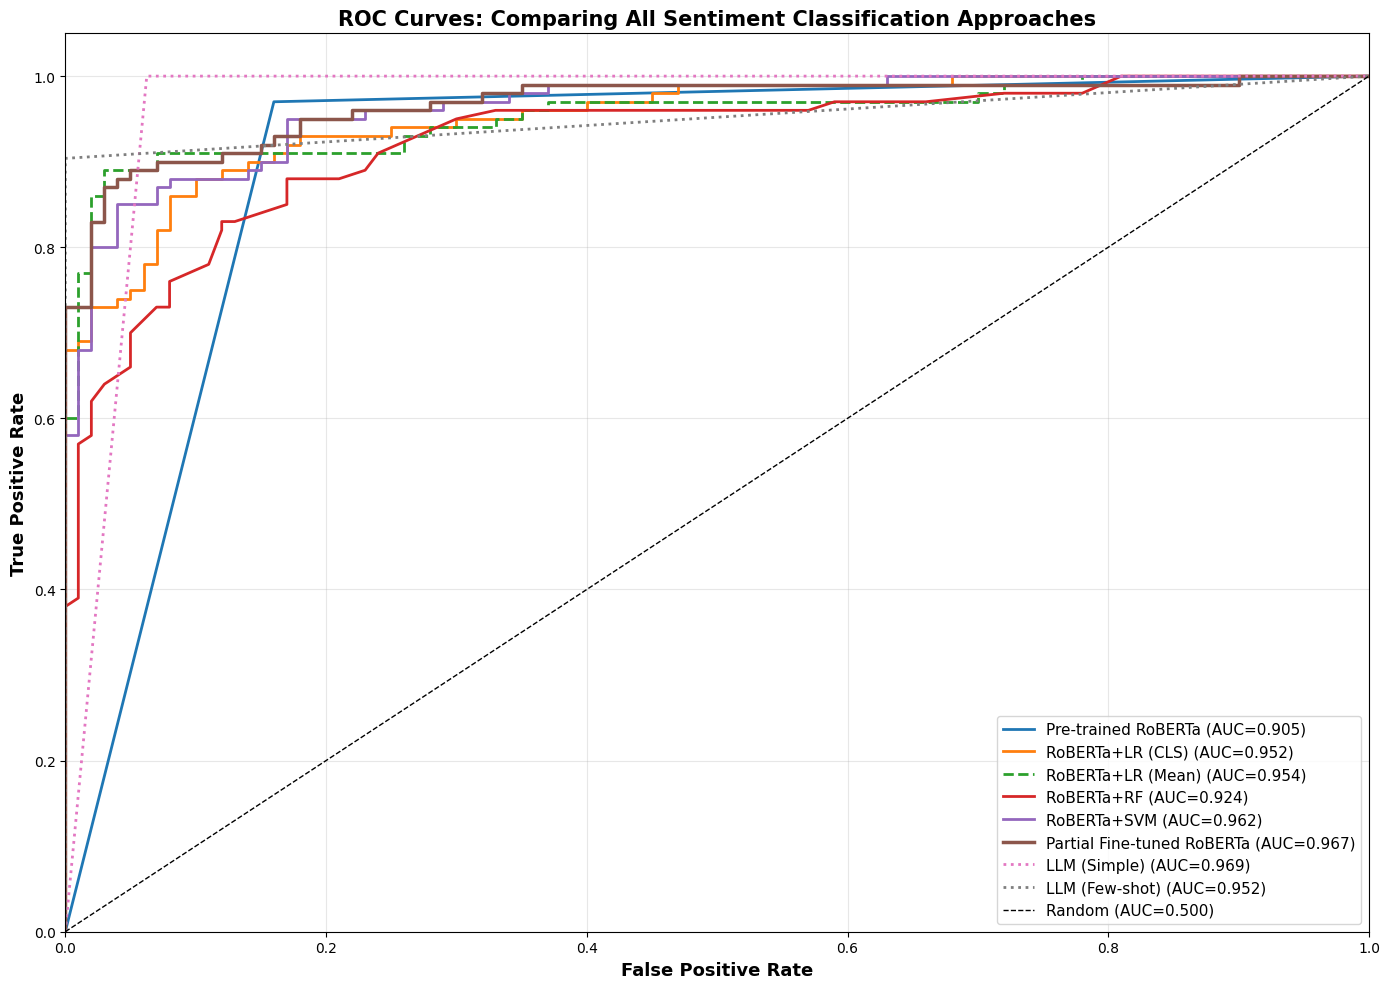

In [50]:
# Plot ROC curves
plt.figure(figsize=(14, 10))

# Define models and their predictions
roc_models = {
    'Pre-trained RoBERTa': (y_test, y_pred_prob_pretrained, '-'),
    'RoBERTa+LR (CLS)': (y_test, y_pred_prob_lr_cls, '-'),
    'RoBERTa+LR (Mean)': (y_test, y_pred_prob_lr_mean, '--'),
    'RoBERTa+RF': (y_test, y_pred_prob_rf_cls, '-'),
    'RoBERTa+SVM': (y_test, y_pred_prob_svm_cls, '-'),
    'Partial Fine-tuned RoBERTa': (y_test, y_pred_prob_finetune, '-'),
}

if OLLAMA_READY:
    roc_models['LLM (Simple)'] = (y_test_sample, y_pred_llm_simple.astype(float), ':')
    roc_models['LLM (Few-shot)'] = (y_test_sample, y_pred_llm_fewshot.astype(float), ':')

# Plot each model
for model_name, (y_true, y_pred_prob, linestyle) in roc_models.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    auc = roc_auc_score(y_true, y_pred_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', 
             linestyle=linestyle, linewidth=2.5 if 'Partial Fine' in model_name else 2)

# Plot random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves: Comparing All Sentiment Classification Approaches', 
          fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Visualize Metrics Comparison

Create **bar plots** comparing all models across different metrics.

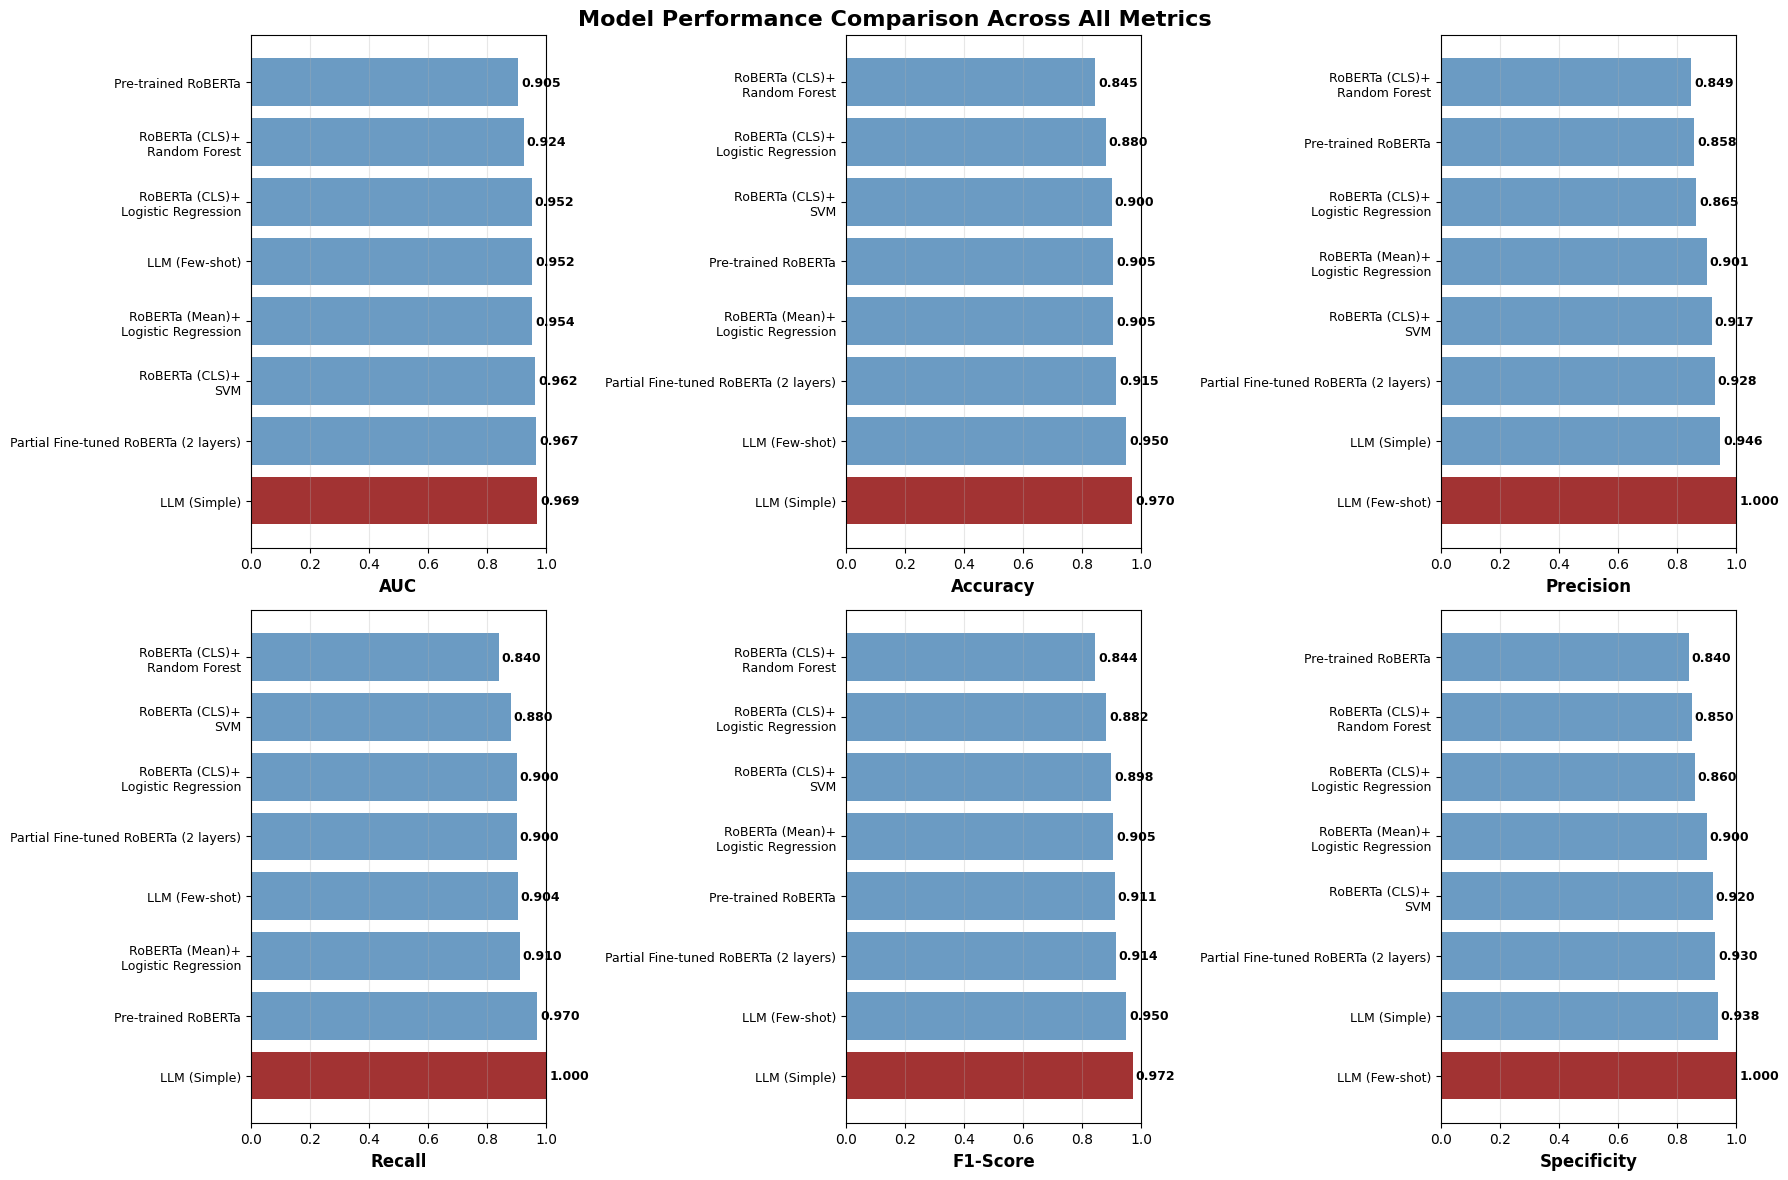

In [46]:
# Create bar plot for metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    data = results_df[metric].sort_values(ascending=False)
    
    # Color bars: best = dark, others = light
    colors = ['darkred' if i == 0 else 'steelblue' for i in range(len(data))]
    
    bars = ax.barh(range(len(data)), data.values, color=colors, alpha=0.8)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels([name.replace(' + ', '+\n') for name in data.index], fontsize=9)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, data.values)):
        ax.text(value + 0.01, i, f'{value:.3f}', 
                va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison Across All Metrics', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Key insights

1. **Partial fine-tuned RoBERTa (last 2 layers) performs excellently** by adapting ~20M parameters to the specific task

2. **Frozen RoBERTa + Logistic Regression** achieves **excellent performance** (~0.85-0.90 AUC) with much faster training. 

3. **Random Forest and SVM** on RoBERTa embeddings:
   - Can capture non-linear patterns Logistic Regression misses
   - Performance often competitive with LR
   - SVM slower to train but powerful for small datasets

4. **Pre-trained RoBERTa** (zero-shot) achieves **good baseline** an for some metrics even among the top performers. 

5. **LLM prompting**  shows good performance but can be due to the specific subsample. Sentiment analysis of short reviews is fairly straighforward task, so simple LLM prompting works quite well. 


**Comparison to Lecture 4 (LSA + Word2Vec + Doc2Vec)**:
- **RoBERTa embeddings** (frozen) outperform LSA and Doc2Vec significantly
